<a href="https://colab.research.google.com/github/Nikhilesh-Nanda/Spotify-hitOrNot-predictor/blob/main/SPOTIFY_HIT_NOT_HIT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Analyze the Spotify tracks dataset by performing data cleaning, feature engineering, and visualization, then apply various clustering algorithms, and finally build a song recommender system.

# **IMPORTANT REQUIRED LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the '-spotify-tracks-dataset' dataset.
Path to dataset files: /kaggle/input/-spotify-tracks-dataset


In [ ]:
my_data = pd.read_csv("/kaggle/input/-spotify-tracks-dataset/dataset.csv")
my_data.head(10)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
5,5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,214240,False,0.688,0.4810,...,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.6660,98.017,4,acoustic
6,6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,0.1470,...,-8.822,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,3,acoustic
7,7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.4440,...,-9.331,1,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,4,acoustic
8,8,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,0.4140,...,-8.700,1,0.0369,0.2940,0.000000,0.1510,0.6690,130.088,4,acoustic
9,9,7k9GuJYLp2AzqokyEdwEw2,Ross Copperman,Hunger,Hunger,56,205594,False,0.442,0.6320,...,-6.770,1,0.0295,0.4260,0.004190,0.0735,0.1960,78.899,4,acoustic


In [ ]:
my_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [ ]:
y = my_data['artists'].str.split(';')


In [ ]:
z = y.str.join(',')


In [ ]:
my_data['artists'] = z

In [ ]:
my_data['explicit'].value_counts()

,count
explicit,
False,104253
True,9747


In [ ]:
my_data.loc[my_data['explicit'] == False,'explicit'] = 0
my_data.loc[my_data['explicit'] == True,'explicit'] = 1

/tmp/ipykernel_18614/2837254329.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  my_data.loc[my_data['explicit'] == False,'explicit'] = 0


#**DATA HANDLING**

In [ ]:
my_data['track_name'].value_counts()

,count
track_name,
Run Rudolph Run,151
Halloween,88
Frosty The Snowman,81
Little Saint Nick - 1991 Remix,76
Last Last,75
...,...
Sleep My Little Boy,1
Water Into Light,1
Miss Perfumado,1


***Run Rudolph Run*** : The most frequent track name in that column

In [ ]:
my_data['artists'].value_counts()

,count
artists,
The Beatles,279
George Jones,271
Stevie Wonder,236
Linkin Park,224
Ella Fitzgerald,222
...,...
"Hillsong Worship,TAYA,David Ware",1
"for KING & COUNTRY,Andy Mineo",1
"Bethel Music,Francesca Battistelli",1


***The Beatles*** : has the highest count

In [ ]:
my_data['duration_ms'].value_counts()

,count
duration_ms,
162897,146
180000,104
192000,91
240000,84
118840,76
...,...
196570,1
252474,1
224135,1


***162897*** : has the highest count, ***false*** has the highest count for explicit

In [ ]:
only_null_trackName = my_data[my_data['track_name'].isna() == True]
only_null_trackName['track_name'] = 'Run Rudolph Run'
only_null_trackName['artists'] = 'The Beatles'
only_null_trackName['album_name'] = 'Alternative Christmas 2022'
only_null_trackName['duration_ms'] = 162897
only_null_trackName['explicit'] = False


/tmp/ipykernel_18614/715878296.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  only_null_trackName['track_name'] = 'Run Rudolph Run'
/tmp/ipykernel_18614/715878296.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  only_null_trackName['artists'] = 'The Beatles'
/tmp/ipykernel_18614/715878296.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata

In [ ]:
my_data.iloc[65900] = only_null_trackName.iloc[0]

In [ ]:
my_data[my_data['track_name'].isna() == True]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre


In [ ]:
my_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           114000 non-null  object 
 3   album_name        114000 non-null  object 
 4   track_name        114000 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  object 
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [ ]:
my_data.drop(columns='Unnamed: 0', inplace=True)

In [ ]:
my_data.sample(10)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
1352,3VDMcm2WqOQdNpzLqlbp9B,Nero X,Yawa Dey,Yawa Dey,38,260220,0,0.858,0.634,9,-5.085,1,0.0498,0.40600,0.000000,0.0697,0.824,105.018,4,afrobeat
73593,3nhpqun7WsuVUdNeywQeYy,Avrosse,Ultimate Beats PANAM,That Beat - Mad Raf And Tom Zenith Remix,19,365625,0,0.804,0.883,11,-7.371,0,0.0617,0.00107,0.775000,0.1460,0.249,128.014,4,minimal-techno
7300,2XgGdD5d2MW4RNx8KnIjVh,Old Crow Medicine Show,O.C.M.S.,Wagon Wheel,67,232133,0,0.621,0.403,9,-8.211,1,0.0359,0.58100,0.000000,0.1140,0.634,145.523,4,bluegrass
65871,3ZVKzrWt3efdPVLmiYdr6M,"Yuvan Shankar Raja,Ranjith Govind",Anjaan (Original Motion Picture Soundtrack),Bang Bang Bang,44,250956,0,0.832,0.870,1,-5.328,1,0.0463,0.05750,0.023800,0.2250,0.656,115.016,4,k-pop
74466,0PP1ftXtSyoCPOrd655g9T,Lagum,Coisas da Geração,Fale Mais,42,168640,0,0.675,0.431,4,-11.489,1,0.0328,0.65900,0.000064,0.1140,0.217,144.922,4,mpb
95234,0lSCvI4d5XvMcdYiT2JsTl,Cuco Valoy,Gold,El Aborto,34,218071,0,0.563,0.737,11,-10.923,0,0.0388,0.30300,0.001340,0.2160,0.952,96.146,4,salsa
75758,2BpiNvXMVZnAXGnLrMitZp,Gregorian,Masters of Chant X: The Final Chapter (Tour Ed...,Shout,21,299889,0,0.536,0.748,7,-7.344,0,0.0308,0.01980,0.009920,0.1570,0.303,98.014,4,new-age
75486,1Su3DSrGTjhBfEc1egNUk2,Dan Gibson's Solitudes,Angels of the Sea,Angels of the Sea,23,424412,0,0.185,0.353,9,-21.993,0,0.0609,0.61500,0.105000,0.8080,0.112,119.563,4,new-age
48532,4Ch840cQWjDI9pCkcT0lfh,Bullet Bane,BLLT,Esse Vazio Ocupa Tanto Espaço,31,240762,0,0.452,0.939,4,-4.301,0,0.0474,0.00688,0.000000,0.1720,0.288,142.072,4,hardcore
19360,2ZfojROyvVjM7dQYa0bTJr,Gabby Barrett,New Country,Pick Me Up,0,169440,0,0.472,0.701,2,-4.563,1,0.0369,0.03870,0.000000,0.1070,0.515,79.805,4,country


Japanese in trackname, albumname

In [ ]:
y = my_data['track_name'].str.lower()
y = y.str.title()

In [ ]:
my_data['track_name'] = y

In [ ]:
z = my_data['album_name'].str.lower()
z = z.str.title()


In [ ]:
my_data['album_name'] = z

In [ ]:
my_data.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,"Ingrid Michaelson,ZAYN",To Begin Again,To Begin Again,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can'T Help Falling In Love,71,201933,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


**DURATION IN MILI SECONDS SEEMS NOT TO BE IMPORTANT, CONVERT IT INTO MINUTES AND SECONDS**

In [ ]:
b = my_data['duration_ms']
b = my_data['duration_ms'] / 1000

In [ ]:
mint = b//60
secd = b % 60

In [ ]:
mint = mint.astype(int)

In [ ]:
secd = np.round(secd)

In [ ]:
secd = secd.astype(int)

In [ ]:
my_data['minutes']  = mint
my_data['seconds'] = secd

In [ ]:
my_data.drop(columns='duration_ms', inplace=True)

In [ ]:
my_data.loc[my_data['speechiness'] > 0.66,'trackDesc'] = 'Entire Spoken'

In [ ]:
my_data.loc[(my_data['speechiness'] >= 0.33) & (my_data['speechiness'] <= 0.66),'trackDesc'] = 'Maybe Music and Speech'

In [ ]:
my_data.loc[my_data['speechiness'] < 0.33,'trackDesc'] = 'Music'

In [ ]:
my_data['trackDesc'].sample(10)

,trackDesc
63008,Music
98401,Music
47021,Music
84112,Music
65997,Music
66994,Music
27730,Music
30312,Music
29893,Music
71086,Music


In [ ]:
b = b.astype(int)
b

,duration_ms
0,230
1,149
2,210
3,201
4,198
...,...
113995,384
113996,385
113997,271
113998,283


In [ ]:
a = '小喋日和'
print(a.isalnum())

True


# ***DATA VISUALISATION***

# **POPULATION:**

greater than or = 0.80 : Highly Popular

greater than or = 0.30 && less than 0.80 : Popular

less than 0.30 : Less Popular

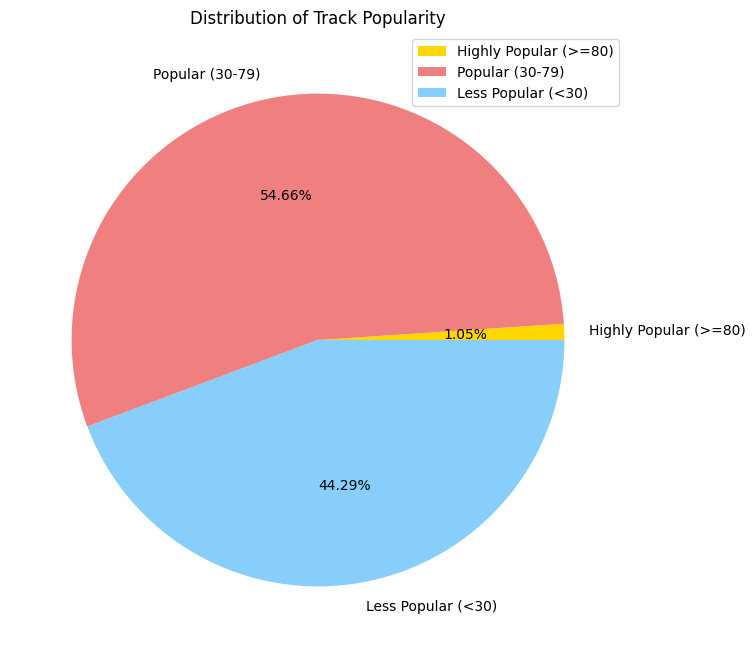

In [ ]:
highPop_count = my_data[my_data['popularity'] >= 80].shape[0]
popl_count = my_data[(my_data['popularity'] >= 30) & (my_data['popularity'] < 80)].shape[0]
lessPop_count = my_data[my_data['popularity'] < 30].shape[0]

popularity_counts = [highPop_count, popl_count, lessPop_count]
popularity_labels = ['Highly Popular (>=80)', 'Popular (30-79)', 'Less Popular (<30)']

plt.figure(figsize=(8, 8))
plt.pie(popularity_counts, labels=popularity_labels, autopct='%0.2f%%',colors=['gold', 'lightcoral', 'lightskyblue'])

plt.title('Distribution of Track Popularity')
plt.legend()
plt.show()

# **Danceability**

greater than 0.70 : High

greater or = 0.40 & less or = 0.70: Middle

less than 0.40 : Low

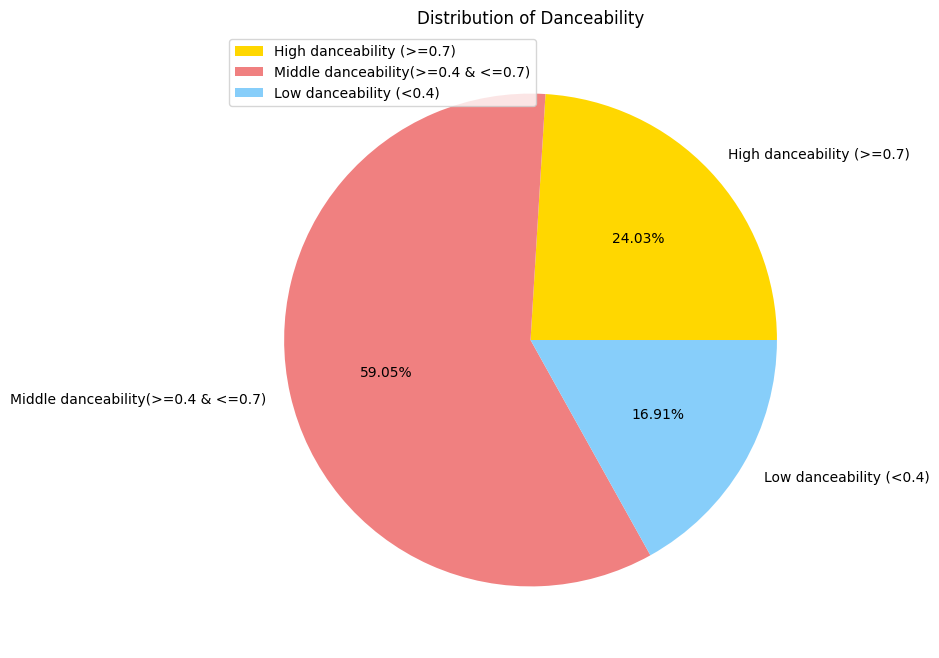

In [ ]:
midDan_count = my_data[(my_data['danceability'] >= 0.40) & (my_data['danceability'] <= 0.70)].shape[0]
highDan_count = my_data[my_data['danceability'] >= 0.7].shape[0]
lowDan_count = my_data[my_data['danceability'] < 0.4].shape[0]

danceabilityCnt = [highDan_count, midDan_count, lowDan_count]
danceability_labels = ['High danceability (>=0.7)', 'Middle danceability(>=0.4 & <=0.7)', 'Low danceability (<0.4)']

plt.figure(figsize=(8, 8))
plt.pie(danceabilityCnt, labels=danceability_labels, autopct='%0.2f%%',colors=['gold', 'lightcoral', 'lightskyblue'])

plt.title('Distribution of Danceability')
plt.legend()
plt.show()

# **Energy**
greater than 0.70 : High

greater or = 0.40 & less or = 0.70: Middle

less than 0.40 : Low

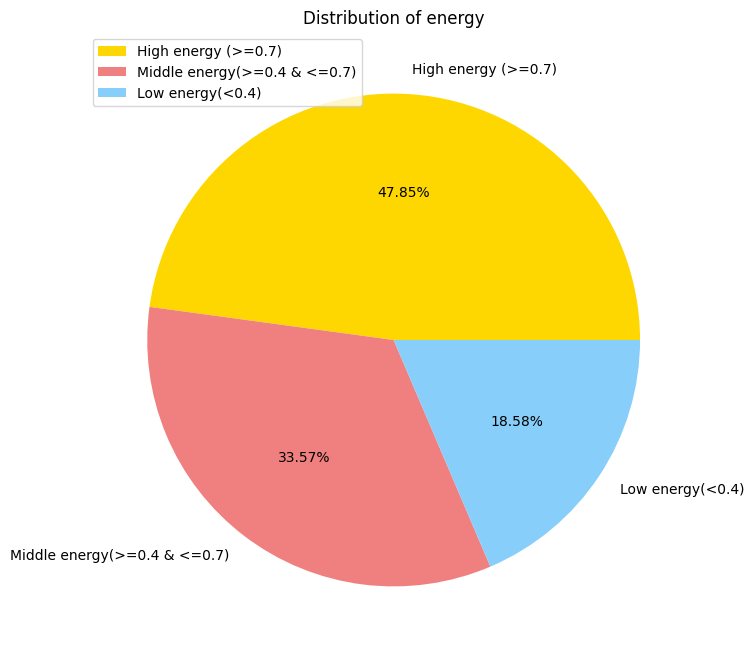

In [ ]:
midErg_count = my_data[(my_data['energy'] >= 0.40) & (my_data['energy'] <= 0.70)].shape[0]
highErg_count = my_data[my_data['energy'] >= 0.7].shape[0]
lowErg_count = my_data[my_data['energy'] < 0.4].shape[0]

danceabilityCnt = [highErg_count, midErg_count, lowErg_count]
danceability_labels = ['High energy (>=0.7)', 'Middle energy(>=0.4 & <=0.7)', 'Low energy(<0.4)']

plt.figure(figsize=(8, 8))
plt.pie(danceabilityCnt, labels=danceability_labels, autopct='%0.2f%%',colors=['gold', 'lightcoral', 'lightskyblue'])

plt.title('Distribution of energy')
plt.legend()

plt.show()


Large portion of the music is highly energetic. Energetic tracks feel fast, loud, and noisy.

# **Loudness**

greater than -5 : High

greater or = -10 & less or = -5: Middle

less than -10 : Low

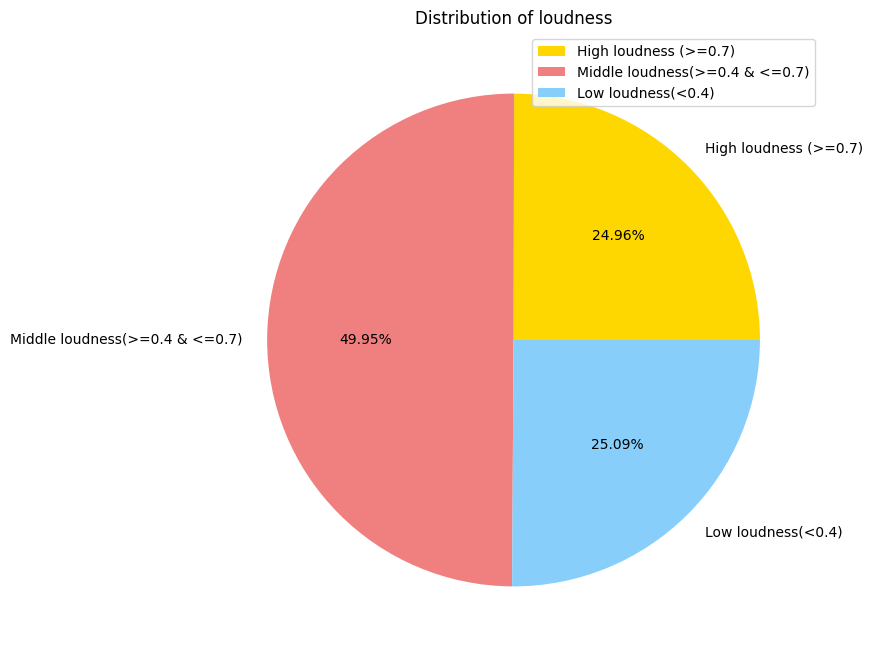

In [ ]:
midloudness_count = my_data[(my_data['loudness'] >= -10) & (my_data['loudness'] <= -5)].shape[0]
highloudness_count = my_data[my_data['loudness'] > -5].shape[0]
lowloudness_count = my_data[my_data['loudness'] < -10].shape[0]

loudnessCnt = [highloudness_count, midloudness_count, lowloudness_count]
loudness_labels = ['High loudness (>=0.7)', 'Middle loudness(>=0.4 & <=0.7)', 'Low loudness(<0.4)']

plt.figure(figsize=(8, 8))
plt.pie(loudnessCnt, labels=loudness_labels, autopct='%0.2f%%',colors=['gold', 'lightcoral', 'lightskyblue'])

plt.title('Distribution of loudness')
plt.legend()

plt.show()

# **Acousticness**
greater than 0.60 : High

greater or = 0.01 & less or = 0.60: Middle

less than 0.01 : Low

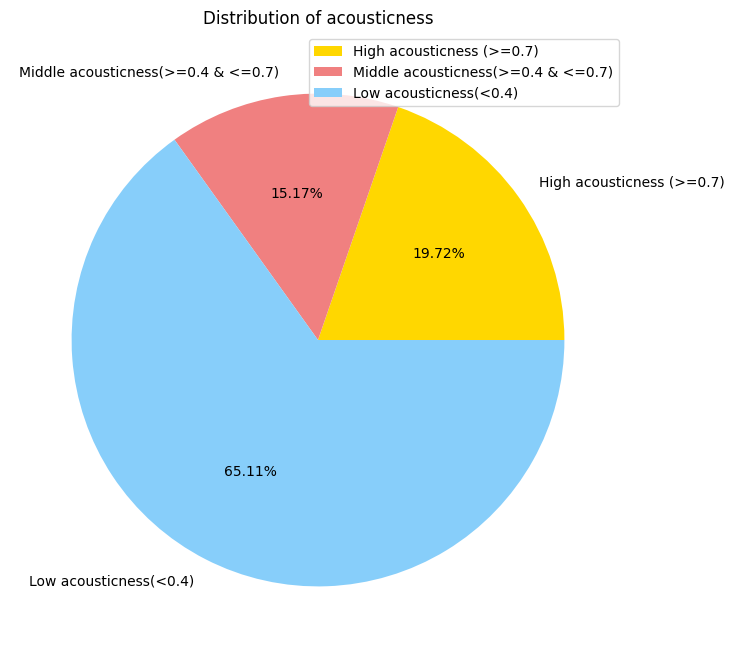

In [ ]:
midacousticness_count = my_data[(my_data['acousticness'] >= 0.40) & (my_data['acousticness'] <= 0.70)].shape[0]
highacousticness_count = my_data[my_data['acousticness'] >= 0.7].shape[0]
lowacousticness_count = my_data[my_data['acousticness'] < 0.4].shape[0]

acousticnessCnt = [highacousticness_count, midacousticness_count, lowacousticness_count]
acousticness_labels = ['High acousticness (>=0.7)', 'Middle acousticness(>=0.4 & <=0.7)', 'Low acousticness(<0.4)']

plt.figure(figsize=(8, 8))
plt.pie(acousticnessCnt, labels=acousticness_labels, autopct='%0.2f%%',colors=['gold', 'lightcoral', 'lightskyblue'])

plt.title('Distribution of acousticness')
plt.legend()

plt.show()

# **Instrumentalness**

greater than 0.049 : High

greater or = 0.000042 & less or = 0.049: Middle

less than 0.000042 : Low

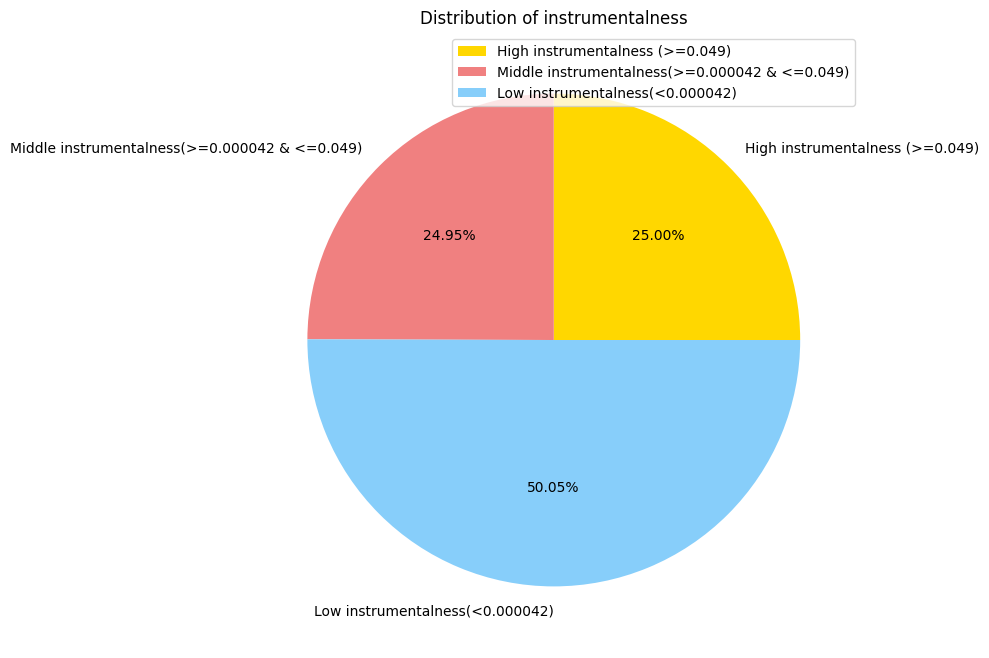

In [ ]:
midinstrumentalness_count = my_data[(my_data['instrumentalness'] >= 0.000042) & (my_data['instrumentalness'] <=0.049)].shape[0]
highinstrumentalness_count = my_data[my_data['instrumentalness'] >= 0.049].shape[0]
lowinstrumentalness_count = my_data[my_data['instrumentalness'] < 0.000042].shape[0]

instrumentalnessCnt = [highinstrumentalness_count, midinstrumentalness_count, lowinstrumentalness_count]
instrumentalness_labels = ['High instrumentalness (>=0.049)', 'Middle instrumentalness(>=0.000042 & <=0.049)', 'Low instrumentalness(<0.000042)']

plt.figure(figsize=(8, 8))
plt.pie(instrumentalnessCnt, labels=instrumentalness_labels, autopct='%0.2f%%',colors=['gold', 'lightcoral', 'lightskyblue'])

plt.title('Distribution of instrumentalness')
plt.legend()

plt.show()

#**Liveness**

Higher liveness values represent an increased probability that the track was performed live. A value above 0.8 provides strong likelihood that the track is live

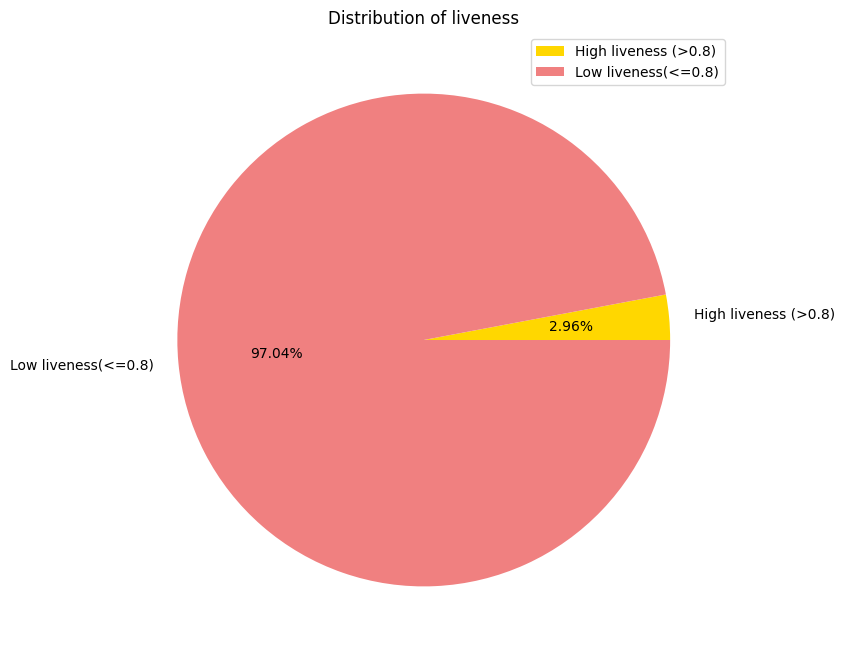

In [ ]:
highLiveness_count = my_data[my_data['liveness'] > 0.8].shape[0]
lowLiveness_count = my_data[my_data['liveness'] <= 0.8].shape[0]

livenessCnt = [highLiveness_count,lowLiveness_count]
liveness_labels = ['High liveness (>0.8)', 'Low liveness(<=0.8)']

plt.figure(figsize=(8, 8))
plt.pie(livenessCnt, labels=liveness_labels, autopct='%0.2f%%',colors=['gold', 'lightcoral'])

plt.title('Distribution of liveness')
plt.legend()

plt.show()

# **Valence**

Tracks with high valence sound more positive (e.g. happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g. sad, depressed, angry)

greater than or = 0.70 : High

else : Low

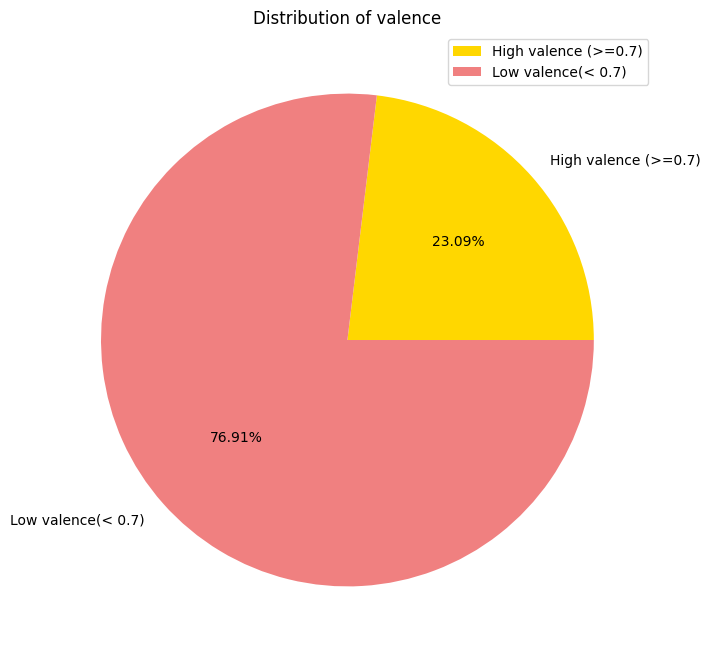

In [ ]:
highvalence_count = my_data[my_data['valence'] >= 0.7].shape[0]
lowvalence_count = my_data[my_data['valence'] < 0.7].shape[0]

valenceCnt = [highvalence_count,lowvalence_count]
valence_labels = ['High valence (>=0.7)', 'Low valence(< 0.7)']

plt.figure(figsize=(8, 8))
plt.pie(valenceCnt, labels=valence_labels, autopct='%0.2f%%',colors=['gold', 'lightcoral'])

plt.title('Distribution of valence')
plt.legend()

plt.show()

# **Handling time issues**

In [ ]:
greaterThan60 = my_data[my_data['minutes']> 60]['minutes']
leftMinutes = greaterThan60 % 60
greaterThan60 = greaterThan60 // 60

In [ ]:
my_data['hours'] = greaterThan60

In [ ]:
my_data.loc[my_data['minutes']> 60,'hours'] = my_data.loc[my_data['minutes']> 60,'hours'].astype(int)


In [ ]:
my_data.loc[my_data['minutes']> 60,'minutes'] = my_data.loc[my_data['minutes']> 60,'minutes'] - 60


In [ ]:
my_data.loc[my_data['hours'].isna() == True,'hours'] = 0

In [ ]:
my_data[my_data['seconds']> 60].shape[0]

0

In [ ]:
my_data['hours'] = my_data['hours'].astype(int)

In [ ]:
my_data['explicit'] = my_data['explicit'].astype(int)

In [ ]:
my_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 23 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           114000 non-null  object 
 2   album_name        114000 non-null  object 
 3   track_name        114000 non-null  object 
 4   popularity        114000 non-null  int64  
 5   explicit          114000 non-null  int64  
 6   danceability      114000 non-null  float64
 7   energy            114000 non-null  float64
 8   key               114000 non-null  int64  
 9   loudness          114000 non-null  float64
 10  mode              114000 non-null  int64  
 11  speechiness       114000 non-null  float64
 12  acousticness      114000 non-null  float64
 13  instrumentalness  114000 non-null  float64
 14  liveness          114000 non-null  float64
 15  valence           114000 non-null  float64
 16  tempo             11

# **TRAINING VARIOUS MODELS**

**Making use of Kmeans++** : To increase the performance of KMeans by selecting cluster centers sensibly, not randomly. Bad selection of centers can lead to bad clusters and performance.

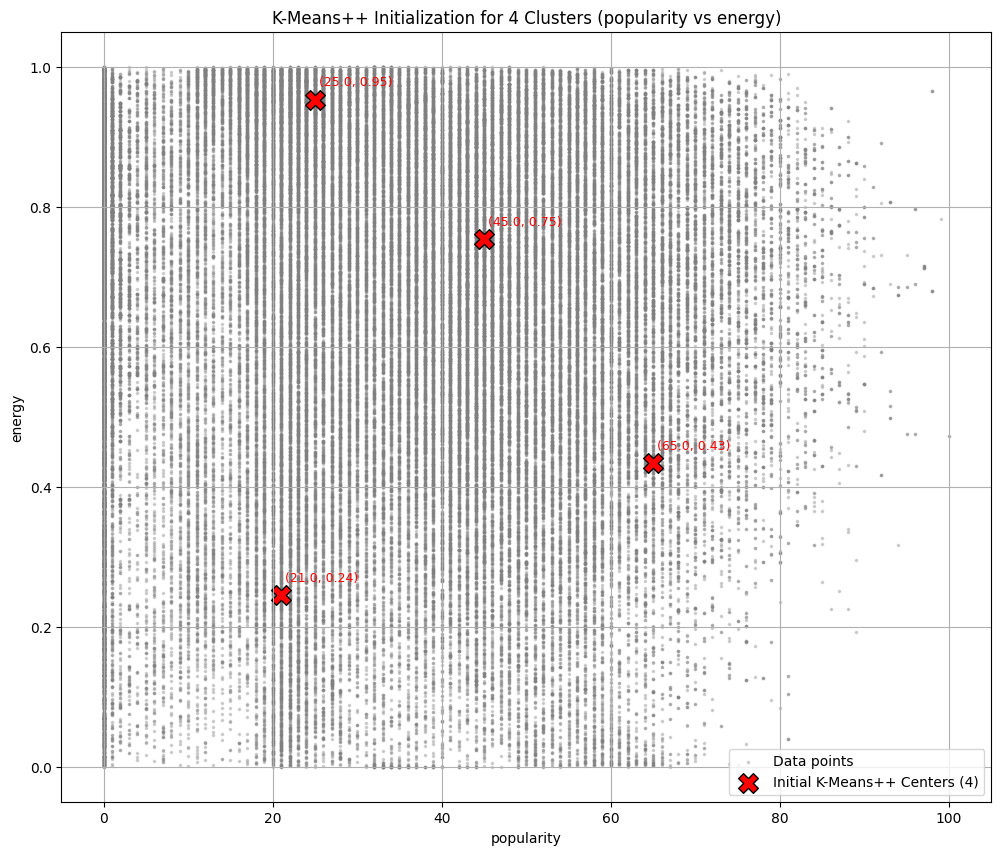

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import kmeans_plusplus

# Assume x is already defined from previous cells as the feature DataFrame
x = my_data[['popularity', 'energy', 'danceability', 'loudness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'mode', 'explicit', 'key', 'speechiness', 'time_signature', 'minutes', 'seconds', 'hours']]

# --- User-configurable features for plotting ---
# Change these two lines to select the features you want to visualize
feature1_name = 'popularity'
feature2_name = 'energy'

# Get the column indices for the selected features from the DataFrame x
feature1_index = x.columns.get_loc(feature1_name)
feature2_index = x.columns.get_loc(feature2_name)

n_clusters_kmeans = 4 # Number of clusters for K-Means++ initialization

# Perform K-Means++ initialization on the feature data
centers_init, indices = kmeans_plusplus(x.values, n_clusters=n_clusters_kmeans, random_state=0)

# Plot the data points and the initial centers
plt.figure(figsize=(12, 10))

# Plot all original data points (2D projection)
plt.scatter(x.iloc[:, feature1_index], x.iloc[:, feature2_index], c='gray', marker=".", s=10, alpha=0.3, label='Data points')

# Plot the initial centers found by K-Means++
plt.scatter(centers_init[:, feature1_index], centers_init[:, feature2_index], c="red", s=200, marker='X', edgecolors='black', label=f'Initial K-Means++ Centers ({n_clusters_kmeans})')

# Add coordinates for the K-Means++ centers
for i, (f1_coord, f2_coord) in enumerate(centers_init[:, [feature1_index, feature2_index]]):
    plt.text(f1_coord + 0.5, f2_coord + 0.02, f'({f1_coord:.1f}, {f2_coord:.2f})', fontsize=9, color='red')

plt.title(f"K-Means++ Initialization for {n_clusters_kmeans} Clusters ({feature1_name} vs {feature2_name})")
plt.xlabel(feature1_name)
plt.ylabel(feature2_name)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
x = my_data[['popularity', 'energy', 'danceability', 'loudness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'mode', 'explicit', 'key', 'speechiness', 'time_signature', 'minutes', 'seconds', 'hours']]
n_clusters_kmeans = 4
k_means = KMeans(init="k-means++",n_clusters=n_clusters_kmeans)
k_means.fit(x)
k_means_labels = k_means.labels_
k_means_cluster_centers = k_means.cluster_centers_
print(centers_init)

[[ 6.50000e+01  4.34000e-01  4.38000e-01 -8.37000e+00  1.22000e-01
   0.00000e+00  1.50000e-01  1.95000e-01  1.79913e+02  1.00000e+00
   0.00000e+00  7.00000e+00  3.71000e-02  4.00000e+00  4.00000e+00
   1.70000e+01  0.00000e+00]
 [ 2.50000e+01  9.53000e-01  4.66000e-01 -6.81400e+00  2.42000e-03
   1.04000e-03  2.50000e-01  7.08000e-01  1.07861e+02  0.00000e+00
   0.00000e+00  1.10000e+01  5.33000e-02  4.00000e+00  2.00000e+00
   1.40000e+01  0.00000e+00]
 [ 4.50000e+01  7.54000e-01  6.19000e-01 -6.50900e+00  1.06000e-01
   6.80000e-05  7.03000e-01  6.29000e-01  1.32975e+02  1.00000e+00
   0.00000e+00  5.00000e+00  3.03000e-02  4.00000e+00  3.00000e+00
   4.00000e+01  0.00000e+00]
 [ 2.10000e+01  2.45000e-01  4.25000e-01 -1.60210e+01  9.29000e-01
   9.03000e-01  6.80000e-01  3.93000e-01  8.79690e+01  1.00000e+00
   0.00000e+00  9.00000e+00  4.00000e-02  4.00000e+00  4.00000e+00
   2.30000e+01  0.00000e+00]]


**KMEANS**

In [ ]:
from sklearn.cluster import KMeans

kmn = KMeans(init='k-means++',n_clusters=4,n_init=15)
kmn.fit(x)
kmn_labels = kmn.labels_
kmn_cluster_centers = kmn.cluster_centers_

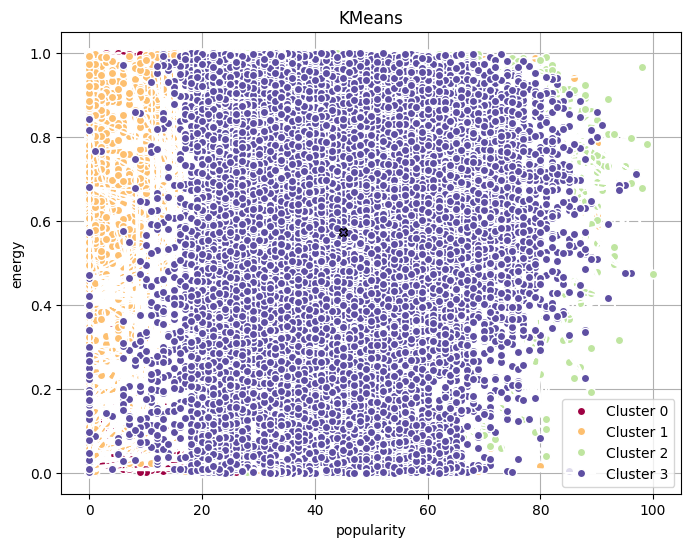

In [ ]:
from matplotlib.markers import MarkerStyle
import matplotlib.pyplot as plt
colors = plt.cm.Spectral(np.linspace(0,1,len(set(kmn_labels))))

plt.figure(figsize=(8,6))
for k,col in zip(range(len(kmn_cluster_centers)),colors):
  my_members = (kmn_labels == k)

  cluster_center = kmn_cluster_centers[k]

  # Corrected indexing for pandas DataFrame and added label for legend
  plt.plot(x.loc[my_members, x.columns[0]], x.loc[my_members, x.columns[1]], 'w', markerfacecolor=col, marker='o', label=f'Cluster {k}')

    # Plots the centroids with specified color, but with a darker outline
  plt.plot(cluster_center[0], cluster_center[1], 'X',markerfacecolor=col,  markeredgecolor='k', markersize=6)

plt.title("KMeans")
plt.grid(True)
plt.xlabel(x.columns[0])
plt.ylabel(x.columns[1])
plt.legend()
plt.show()

In [ ]:
print(len(kmn_labels))

114000


**AGGLOMERATIVE CLUSTERING**

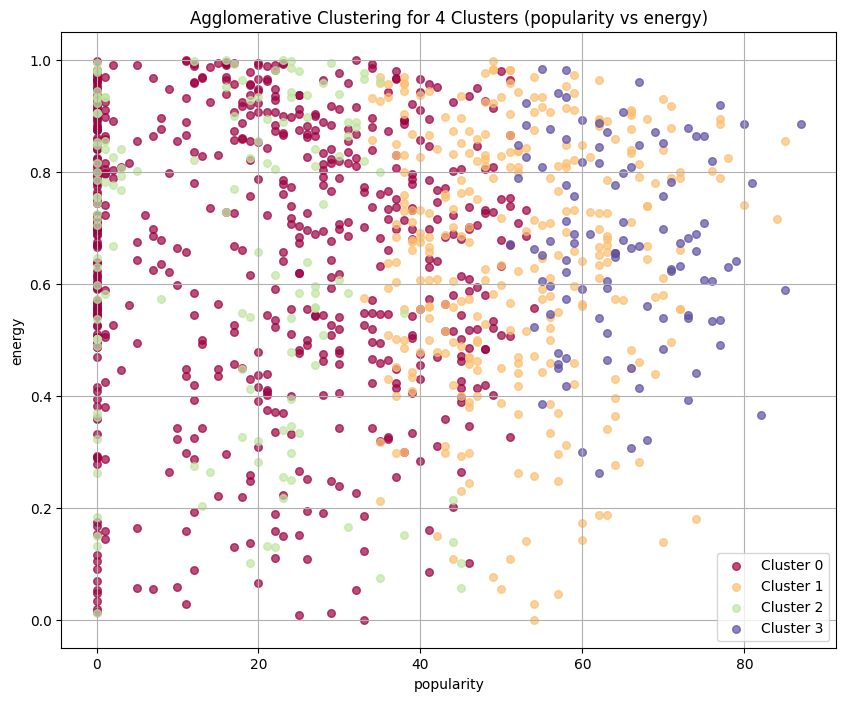

In [ ]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np # Ensure numpy is imported

# Take a sample of the data to avoid memory issues with AgglomerativeClustering on large datasets
# Adjust the fraction (e.g., 0.01 for 1%) as needed based on available memory and desired computation time.
# Using a small sample for demonstration purposes.
my_data_sampled = my_data.sample(frac=0.01, random_state=42) # Sample 1% of the data

x1 = my_data_sampled[['popularity', 'energy', 'danceability', 'loudness', 'acousticness', 'instrumentalness', 'liveness','explicit', 'minutes', 'seconds', 'hours']]
agc = AgglomerativeClustering(n_clusters=4,linkage='complete')
agc.fit(x1)

plt.figure(figsize=(10, 8)) # Adjusted figsize for better readability

# Define feature names for plotting (similar to K-Means example)
feature1_name = 'popularity'
feature2_name = 'energy'

# Get the column indices for the selected features from the DataFrame x1
feature1_index = x1.columns.get_loc(feature1_name)
feature2_index = x1.columns.get_loc(feature2_name)

# Get the cluster labels
labels = agc.labels_
n_clusters = agc.n_clusters

# Get unique labels and map them to colors
unique_labels = np.unique(labels)
colors = cm.Spectral

temp_Members = []
for k in unique_labels:
    # Select data points belonging to the current cluster
    cluster_members = (labels == k)
    temp_Members = cluster_members # This will only store the last cluster_members assigned
    plt.scatter(x1.iloc[cluster_members, feature1_index],
                x1.iloc[cluster_members, feature2_index],
                color=colors(k / (n_clusters - 1.0) if n_clusters > 1 else 0), # Handle single cluster case
                label=f'Cluster {k}',
                alpha=0.7,
                s=30)

plt.title(f'Agglomerative Clustering for {n_clusters} Clusters ({feature1_name} vs {feature2_name})')
plt.xlabel(feature1_name)
plt.ylabel(feature2_name)
plt.legend()
plt.grid(True)
plt.show()

Number of points per cluster out of the sample data

In [ ]:
unique_labels = set(agc.labels_)

agc_df = pd.DataFrame(agc.labels_,columns=['clusterLabel'])
clusterPointsCnt = agc_df.clusterLabel.value_counts().sort_values(ascending=True)

clusterPointsCnt

,count
clusterLabel,
3,103
2,138
1,306
0,593


Average popularity according to each cluster

In [ ]:
avgofLabels = []

for k in unique_labels:
  cluster_members = (labels == k)
  avg = np.mean(x1.iloc[cluster_members,feature1_index])
  avgofLabels.append(avg)

print(avgofLabels)

[np.float64(20.689713322091063), np.float64(52.13725490196079), np.float64(15.673913043478262), np.float64(65.13592233009709)]


**MEAN SHIFT**

In [ ]:
from sklearn.cluster import MeanShift,estimate_bandwidth

bandwidth = estimate_bandwidth(x1, quantile=0.1, n_samples=len(x1))

ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(x1)
labels = ms.labels_
cluster_centers = ms.cluster_centers_

labels_unique = np.unique(labels)
n_clusters_ = len(labels_unique)

print("number of estimated clusters : %d" % n_clusters_)

number of estimated clusters : 5


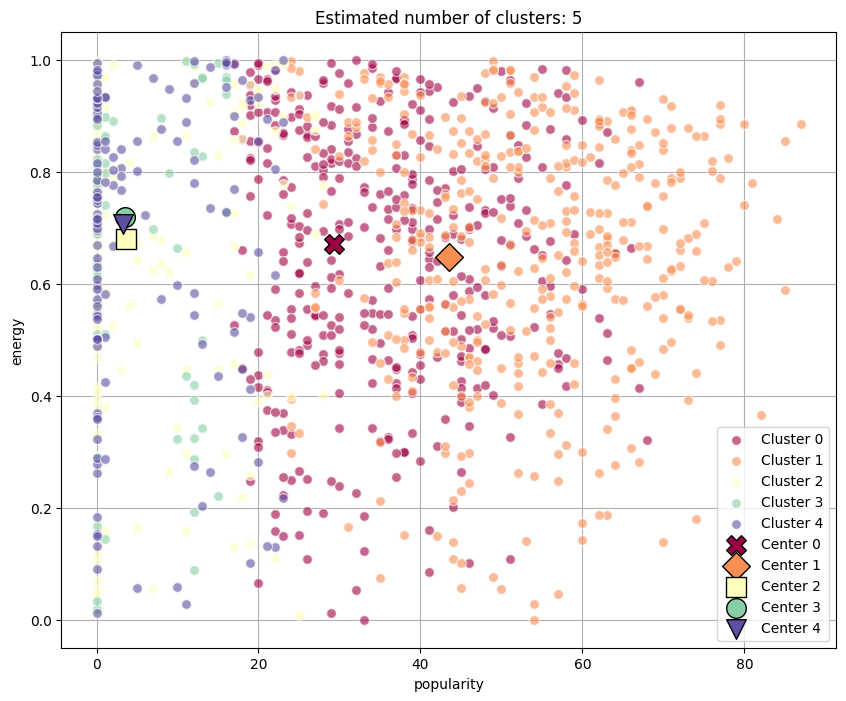

In [ ]:
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported if not already

feature1_name = 'popularity'
feature2_name = 'energy'
feature1_index = x1.columns.get_loc(feature1_name)
feature2_index = x1.columns.get_loc(feature2_name)

plt.figure(figsize=(10, 8))

# Define markers for cluster centers (assuming up to a certain number of clusters)
# This is needed because the original code tried to use `markers[k]`
center_markers = ['X', 'D', 's', 'o', 'v', '^', '<', '>', 'p', '*', 'h', 'H', '+', 'x']

# Get a colormap for distinct colors for each cluster (including noise if present)
n_distinct_clusters = len(labels_unique)
cmap = plt.colormaps.get_cmap('Spectral') # Updated line to use plt.colormaps.get_cmap()

for i, k in enumerate(labels_unique):
    if k == -1:
        # Black used for noise.
        color = 'k'
        edgecolor = 'k'
        marker = '.'
        label_text = 'Noise'
        zorder = 1 # Plot noise behind other clusters
    else:
        color = cmap(i / (n_distinct_clusters - 1.0) if n_distinct_clusters > 1 else 0) # Apply normalized index to colormap
        edgecolor = 'w' # White edge for data points
        marker = 'o'
        label_text = f'Cluster {k}'
        zorder = 2

    my_members = (labels == k)

    # Plot data points
    plt.scatter(x1.iloc[my_members, feature1_index],
                x1.iloc[my_members, feature2_index],
                c=[color], # c expects a list of colors or single color
                marker=marker,
                edgecolor=edgecolor,
                s=50 if k != -1 else 20, # Larger points for clusters, smaller for noise
                alpha=0.6,
                label=label_text,
                zorder=zorder)

# Plot the cluster centers separately
# Ensure cluster_centers is used as the array of centers
for i, center in enumerate(cluster_centers):
    # Only plot centers for actual clusters, not noise (noise doesn't have a center)
    # Check if 'i' corresponds to a valid cluster index (0 to n_clusters_ - 1)
    if i < n_clusters_:
        center_color = cmap(i / (n_distinct_clusters - 1.0) if n_distinct_clusters > 1 else 0) # Apply normalized index to colormap
        plt.scatter(
            center[feature1_index],
            center[feature2_index],
            marker=center_markers[i % len(center_markers)], # Use different markers for centers
            facecolor=center_color,
            edgecolor="k", # Black outline for centers
            s=200, # Larger size for centers
            label=f'Center {i}',
            zorder=3 # Plot centers on top
        )


plt.title("Estimated number of clusters: %d" % n_clusters_)
plt.xlabel(feature1_name)
plt.ylabel(feature2_name)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
cluster_centers

array([[29.33014354,  0.67012928,  0.54976986, -7.5182823 ,  0.29939557,
         0.13908837,  0.22988995,  0.08133971,  3.32535885, 31.01913876,
         0.        ],
       [43.52542373,  0.64751977,  0.55050282, -7.47462147,  0.32319338,
         0.1059752 ,  0.22965085,  0.0960452 ,  3.59322034, 16.75706215,
         0.        ],
       [ 3.67375887,  0.6800922 ,  0.57736879, -7.84444681,  0.23117544,
         0.18527297,  0.20144681,  0.07801418,  2.75886525, 47.17730496,
         0.        ],
       [ 3.5620438 ,  0.71975182,  0.59335766, -7.15051095,  0.20614155,
         0.16751569,  0.18601752,  0.10218978,  3.10218978, 31.40875912,
         0.        ],
       [ 3.23880597,  0.70738731,  0.594     , -6.79976866,  0.24411655,
         0.13725656,  0.21379552,  0.07462687,  3.47761194, 15.94776119,
         0.        ]])

**DBSCAN**

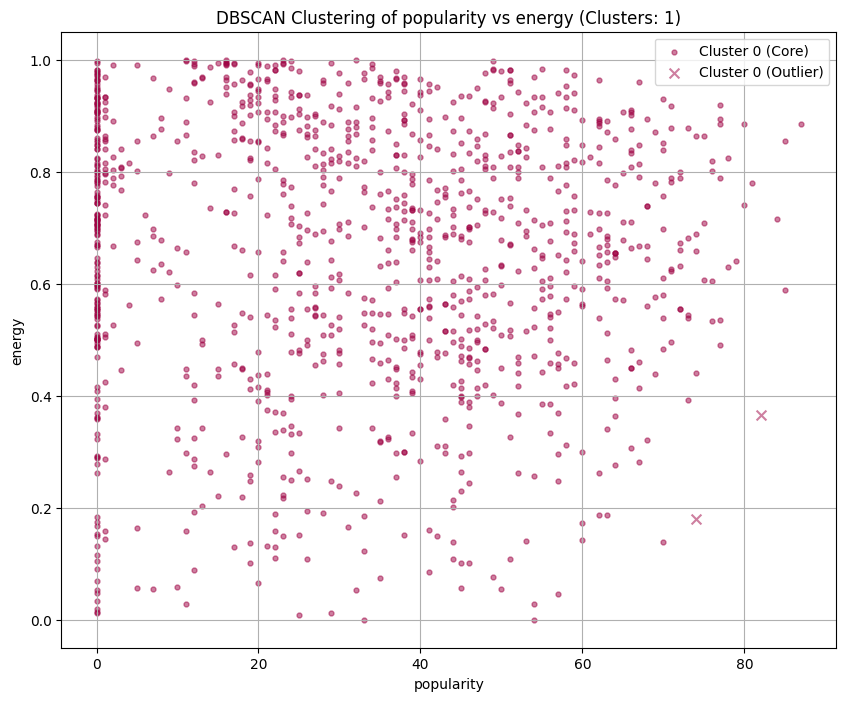

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Take a sample of the data to avoid memory issues with DBSCAN on large datasets
# Adjust the fraction (e.g., 0.01 for 1%) as needed based on available memory and desired computation time.
my_data_sampled_dbscan = my_data.sample(frac=0.01, random_state=42) # Sample 1% of the data
x = my_data_sampled_dbscan[['popularity','energy']]

# --- User-configurable features for plotting ---
feature1_name = 'popularity'
feature2_name = 'energy'

# Get the column indices for the selected features
feature1_index = x.columns.get_loc(feature1_name)
feature2_index = x.columns.get_loc(feature2_name)

# Scale the features for DBSCAN
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

epsilon = 0.5 # A common starting point for scaled data
min_samples = 5

dbs = DBSCAN(eps=epsilon,min_samples=min_samples)
dbs.fit(x_scaled)

labels = dbs.labels_

core_sample_mask = np.zeros_like(labels, dtype=bool)
core_sample_mask[dbs.core_sample_indices_] = True
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
unique_labels = set(labels)

colors = plt.cm.Spectral(np.linspace(0,1,len(unique_labels)))

plt.figure(figsize=(10, 8)) # Added figure and figsize

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = 'k'

    class_member_mask = (labels == k)

    # Plot the datapoints that are clustered
    # Use the original (unscaled) data for plotting, but indexed by the scaled data's labels
    xy_core = x[class_member_mask & core_sample_mask].values
    plt.scatter(xy_core[:, feature1_index], xy_core[:, feature2_index], s=50, c=[col], marker=u'.', alpha=0.5, label=f'Cluster {k} (Core)')

    # Plot the outliers
    xy_outliers = x[class_member_mask & ~core_sample_mask].values
    plt.scatter(xy_outliers[:, feature1_index], xy_outliers[:, feature2_index], s=50, c=[col], marker=u'x', alpha=0.5, label=f'Cluster {k} (Outlier)')

plt.title(f'DBSCAN Clustering of {feature1_name} vs {feature2_name} (Clusters: {n_clusters})')
plt.xlabel(feature1_name)
plt.ylabel(feature2_name)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(set(labels))

{np.int64(0)}


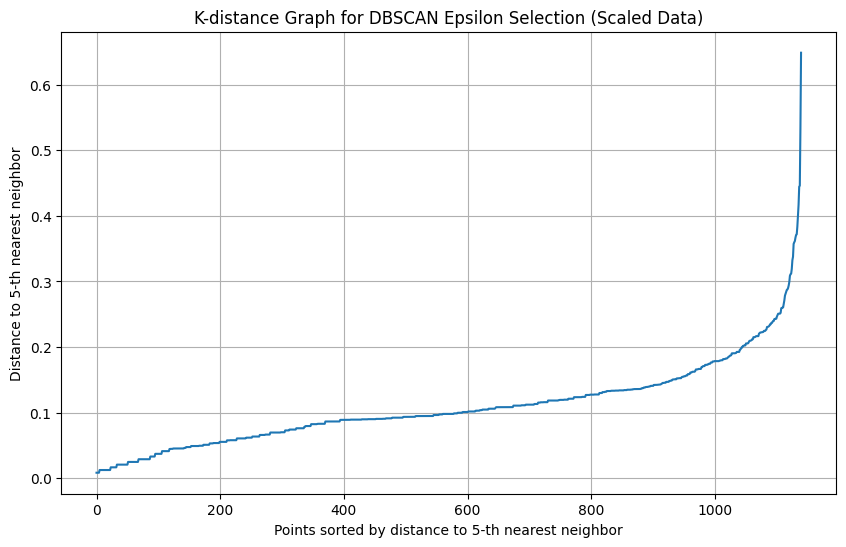

In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Scale the features for DBSCAN
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Calculate the distance to the k-th nearest neighbor for each point
k = min_samples
# Use the scaled data for NearestNeighbors
neigh = NearestNeighbors(n_neighbors=k)
neigh.fit(x_scaled)
distances, indices = neigh.kneighbors(x_scaled)

# Sort distances and plot them
distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('K-distance Graph for DBSCAN Epsilon Selection (Scaled Data)')
plt.xlabel('Points sorted by distance to {}-th nearest neighbor'.format(k))
plt.ylabel('Distance to {}-th nearest neighbor'.format(k))
plt.grid(True)
plt.show()

AgglomerativeClustering(linkage='average', n_clusters=4)

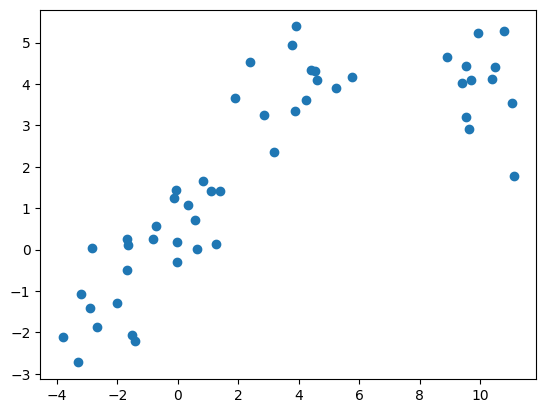

In [ ]:
import numpy as np
import pandas as pd
from scipy import ndimage
from scipy.cluster import hierarchy
from scipy.spatial import distance_matrix
from matplotlib import pyplot as plt
from sklearn import manifold, datasets
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs

X1, y1 = make_blobs(n_samples=50, centers=[[4,4], [-2, -1], [1, 1], [10,4]], cluster_std=0.9)
plt.scatter(X1[:, 0], X1[:, 1], marker='o')

agglom = AgglomerativeClustering(n_clusters = 4, linkage = 'average')
agglom.fit(X1,y1)



In [ ]:
print(agglom.labels_)

[0 2 2 1 2 1 3 3 0 1 3 2 2 1 3 1 3 0 3 2 1 2 2 1 3 0 3 0 0 1 0 1 0 0 2 2 2
 3 1 3 1 0 0 3 2 1 2 3 3 0]


Define 'Hit' Song: Create a new binary column is_hit in your DataFrame. A song will be labeled as a 'hit' (1) if its popularity score is greater than 70; otherwise, it will be a 'not hit' (0). This will be our target variable for classification.


ntegrate Clustering Results as Features: Add the cluster assignments from your K-Means clustering (the k_means_labels) as a new categorical feature, for example, kmeans_cluster, to your main DataFrame. This allows the predictive model to utilize the groupings identified by the clustering algorithm as an input feature.


Prepare Features and Target: Select the relevant audio features (e.g., 'danceability', 'energy', 'loudness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'speechiness', 'explicit', 'key', 'time_signature', 'minutes', 'seconds', 'hours') along with the newly created kmeans_cluster feature to form your independent variables (X). Set the is_hit column as your target variable (y).


Split Data into Training and Testing Sets: Divide your dataset into training and testing sets, for instance, an 80/20 split. It's crucial to use stratified splitting (stratify=y) to ensure that the proportions of 'hit' and 'not hit' songs are maintained in both the training and testing datasets, especially if there's class imbalance.


Scale Features: Apply StandardScaler to your numerical features (including the kmeans_cluster feature, which the scaler will treat numerically). This standardization step is important for many machine learning algorithms to perform optimally by normalizing the data.


Train a Classification Model: Initialize and train a classification model, such as LogisticRegression, using your scaled training data. If there is a significant class imbalance between 'hit' and 'not hit' songs, consider using class_weight='balanced' to adjust the model's sensitivity to the minority class.


Make Predictions: Use the trained classification model to predict whether songs in the scaled test set are 'hit' or 'not hit'. You can also retrieve prediction probabilities for more nuanced insights.


Evaluate Model Performance: Evaluate the model's effectiveness by calculating key metrics like Accuracy, Precision, Recall, and F1-Score. Additionally, generate and visualize a Confusion Matrix to understand the types of correct and incorrect predictions made by the model. Ensure the visualization includes appropriate titles and labels.


Final Task: Summarize the findings from the classification model, including its performance in identifying 'hit' songs. Discuss how this model can serve as a core component for a content-based recommender system, suggesting next steps for personalized recommendations.

**Building recommender system**

Making use of feature engineering

In [ ]:
my_data.loc[my_data['popularity'] > 70,'isHit'] = 1
my_data.loc[my_data['popularity'] <= 70,'isHit'] = 0

In [ ]:
my_data['isHit'] = my_data['isHit'].astype(int)

In [ ]:
my_data['isHit']

,isHit
0,1
1,0
2,0
3,1
4,1
...,...
113995,0
113996,0
113997,0
113998,0


**Evaluating different clustering models**

In [ ]:
from sklearn.metrics import silhouette_score,davies_bouldin_score,calinski_harabasz_score
from sklearn.cluster import KMeans
import numpy as np # Ensure numpy is imported for nan handling if needed

# Current 'x' is the sampled 2-feature data from DBSCAN
# my_data_sampled_dbscan[['popularity','energy']] (1140 samples)

# Define 'x1' explicitly from its origin to ensure consistency for Aglo and MeanShift
# This `x1` was created in cell 's0XbaCZYVxfH' for Agglomerative and MeanShift.
x1 = my_data_sampled[['popularity', 'energy', 'danceability', 'loudness', 'acousticness', 'instrumentalness', 'liveness','explicit', 'minutes', 'seconds', 'hours']]

# Re-run K-Means on the current 'x' (2 features, sampled data) to get consistent labels for evaluation
n_clusters_kmeans = 4 # Use the same number of clusters as before
kmn_sampled = KMeans(init="k-means++", n_clusters=n_clusters_kmeans, n_init=15, random_state=0)
kmn_sampled.fit(x) # Fit on the 2-feature sampled data
kmn_labels_sampled = kmn_sampled.labels_

print("----------------------K MEANS---------------------")
# Use the newly computed labels and the corresponding 'x' for evaluation
silKMeans = silhouette_score(x, kmn_labels_sampled)
davKMeans = davies_bouldin_score(x, kmn_labels_sampled)
calKMeans = calinski_harabasz_score(x, kmn_labels_sampled)
print(f"Silhouette Score (KMeans): {silKMeans:.3f}")
print(f"Davies-Bouldin Score (KMeans): {davKMeans:.3f}")
print(f"Calinski-Harabasz Score (KMeans): {calKMeans:.3f}")


print("\n-----------------AGLOMERATIVE CLUSTERING------------------")
# Agglomerative clustering was fitted on 'x1' (11 features, sampled data)
# So, use 'x1' for its evaluation metrics.
silAglo = silhouette_score(x1, agc.labels_)
davAglo = davies_bouldin_score(x1, agc.labels_)
calAglo = calinski_harabasz_score(x1, agc.labels_)
print(f"Silhouette Score (Agglomerative): {silAglo:.3f}")
print(f"Davies-Bouldin Score (Agglomerative): {davAglo:.3f}")
print(f"Calinski-Harabasz Score (Agglomerative): {calAglo:.3f}")


print("\n--------------MEAN SHIFT----------------------------")
# Mean Shift was fitted on 'x1' (11 features, sampled data)
# So, use 'x1' for its evaluation metrics.
# Ensure that n_clusters_ is greater than 1 for silhouette_score, as it fails for 1 cluster.
# ms.labels_ already exists.
if len(np.unique(ms.labels_)) > 1:
    silMeanS = silhouette_score(x1, ms.labels_)
    davMeanS = davies_bouldin_score(x1, ms.labels_)
    calMeanS = calinski_harabasz_score(x1, ms.labels_)
    print(f"Silhouette Score (Mean Shift): {silMeanS:.3f}")
    print(f"Davies-Bouldin Score (Mean Shift): {davMeanS:.3f}")
    print(f"Calinski-Harabasz Score (Mean Shift): {calMeanS:.3f}")
else:
    print("Mean Shift resulted in 1 cluster, cannot compute silhouette, davies_bouldin, or calinski_harabasz scores.")


print("\n-----------------------DB SCAN-------------------------")
# DBSCAN was fitted on 'x_scaled' (derived from 'x', 2 features, sampled data)
# Use 'x' for its evaluation metrics.
# Ensure that n_clusters is greater than 1 for silhouette_score, as it fails for 1 cluster.
silDB = -1
davDB = -1
calDB = -1
if len(np.unique(dbs.labels_)) > 1: # -1 is noise, so unique labels might be just [-1] or [-1, 0] etc.
    # Filter out noise points for evaluation if they exist and are the only cluster
    labels_filtered = dbs.labels_[dbs.labels_ != -1]
    x_filtered = x[dbs.labels_ != -1]

    if len(np.unique(labels_filtered)) > 1 and len(labels_filtered) > 1:
        silDB = silhouette_score(x_filtered, labels_filtered)
        davDB = davies_bouldin_score(x_filtered, labels_filtered)
        calDB = calinski_harabasz_score(x_filtered, labels_filtered)
        print(f"Silhouette Score (DB Scan): {silDB:.3f}")
        print(f"Davies-Bouldin Score (DB Scan): {davDB:.3f}")
        print(f"Calinski-Harabasz Score (DB Scan): {calDB:.3f}")
    else:
        print("DBSCAN resulted in 0 or 1 valid clusters (excluding noise), cannot compute scores.")
else:
    print("DBSCAN resulted in 1 cluster (or all noise), cannot compute scores.")


----------------------K MEANS---------------------
Silhouette Score (KMeans): 0.618
Davies-Bouldin Score (KMeans): 0.469
Calinski-Harabasz Score (KMeans): 5747.949

-----------------AGLOMERATIVE CLUSTERING------------------
Silhouette Score (Agglomerative): 0.238
Davies-Bouldin Score (Agglomerative): 0.961
Calinski-Harabasz Score (Agglomerative): 537.427

--------------MEAN SHIFT----------------------------
Silhouette Score (Mean Shift): 0.244
Davies-Bouldin Score (Mean Shift): 1.142
Calinski-Harabasz Score (Mean Shift): 544.726

-----------------------DB SCAN-------------------------
DBSCAN resulted in 1 cluster (or all noise), cannot compute scores.


KMeans turn out to be the best performing model for further processing.

In [ ]:
data_to_give = {
    'KMEANS': [silKMeans, davKMeans, calKMeans],
    'AGGLOMERATIVE': [silAglo, davAglo, calAglo],
    'MEAN-SHIFT': [silMeanS, davMeanS, calMeanS],
    'DB-SCAN': [silDB, davDB, calDB]
}

results_Data = pd.DataFrame(data_to_give, index=["Silhouette Score","Davies-Bouldin Score","Calinski-Harabasz Score"]).T
results_Data.head(10)

,Silhouette Score,Davies-Bouldin Score,Calinski-Harabasz Score
KMEANS,0.618486,0.469286,5747.949406
AGGLOMERATIVE,0.237508,0.961035,537.427140
MEAN-SHIFT,0.244391,1.142320,544.725541
DB-SCAN,-1.000000,-1.000000,-1.000000


In [ ]:
my_data['kmeans_cluster'] = kmn_labels

**TRAINING MULTIPLE CLASSIFICATION MODELS**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Re-introducing 'kmeans_cluster' as a feature to integrate clustering results
X = my_data[['energy', 'danceability', 'loudness', 'acousticness',
       'instrumentalness', 'liveness', 'explicit', 'minutes', 'seconds',
       'hours', 'key', 'speechiness', 'time_signature', 'kmeans_cluster']]

y = my_data['isHit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numerical features, including 'kmeans_cluster'
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


dt_metrics = {}
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train_scaled,y_train)
dtc_pred = dtc.predict(X_test_scaled)

dt_metrics['accuracy'] = accuracy_score(y_test,dtc_pred)
dt_metrics['precision'] = precision_score(y_test,dtc_pred)
dt_metrics['recall'] = recall_score(y_test,dtc_pred)
dt_metrics['f1_score'] = f1_score(y_test,dtc_pred)


rf_metrics = {}
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train_scaled,y_train)
rfc_pred = rfc.predict(X_test_scaled)

rf_metrics['accuracy'] = accuracy_score(y_test,rfc_pred)
rf_metrics['precision'] = precision_score(y_test,rfc_pred)
rf_metrics['recall'] = recall_score(y_test,rfc_pred)
rf_metrics['f1_score'] = f1_score(y_test,rfc_pred)


gbc_metrics = {}
gbc = GradientBoostingClassifier(random_state=42)
gbc.fit(X_train_scaled,y_train)
gbc_pred = gbc.predict(X_test_scaled)

gbc_metrics['accuracy'] = accuracy_score(y_test,gbc_pred)
gbc_metrics['precision'] = precision_score(y_test,gbc_pred)
gbc_metrics['recall'] = recall_score(y_test,gbc_pred)
gbc_metrics['f1_score'] = f1_score(y_test,gbc_pred)


hgbc_metrics = {}
hgbc = HistGradientBoostingClassifier(random_state=42)
hgbc.fit(X_train_scaled,y_train)
hgbc_pred = hgbc.predict(X_test_scaled)

hgbc_metrics['accuracy'] = accuracy_score(y_test,hgbc_pred)
hgbc_metrics['precision'] = precision_score(y_test,hgbc_pred)
hgbc_metrics['recall'] = recall_score(y_test,hgbc_pred)
hgbc_metrics['f1_score'] = f1_score(y_test,hgbc_pred)


lr_metrics = {}
lr = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
lr.fit(X_train_scaled,y_train)
lr_pred = lr.predict(X_test_scaled)

lr_metrics['accuracy'] = accuracy_score(y_test,lr_pred)
lr_metrics['precision'] = precision_score(y_test,lr_pred)
lr_metrics['recall'] = recall_score(y_test,lr_pred)
lr_metrics['f1_score'] = f1_score(y_test,lr_pred)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
final_results = {}
final_results['DecisionTree'] = dt_metrics
final_results['RandomForest'] = rf_metrics
final_results['GradientBoosting'] = gbc_metrics
final_results['HistGradientBoosting'] = hgbc_metrics
final_results['LogisticRegression'] = lr_metrics


end_results = pd.DataFrame(final_results)
end_results.index = end_results.index.str.upper()
end_results.head()

,DecisionTree,RandomForest,GradientBoosting,HistGradientBoosting,LogisticRegression
ACCURACY,0.960175,0.982237,0.9575,0.958904,0.685789
PRECISION,0.525227,0.939252,0.0000,0.847826,0.098613
RECALL,0.655315,0.622291,0.0000,0.040248,0.785346
F1_SCORE,0.583104,0.748603,0.0000,0.076847,0.175224


RANDOM FOREST IS THE BEST PERFORMING MODEL, ACCORDING TO THE ABOVE RESULTS

PERFORMING CROSS VALIDATION ON THE BEST MODEL

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators':[None,10,20,30,40],
    'max_depth':[None,10,20,30,40,50],
    'min_samples_split':[2,5,8],
    'min_samples_leaf':[1,2,3]
}

best_perform = rfc
random_best = RandomizedSearchCV(estimator=best_perform,param_distributions=param_grid,n_iter=10,cv=5)
random_best.fit(X_train,y_train)

random_pred = random_best.predict(X_test)
print("----------------------------------------------FINAL RESULTS AFTER CROSS VALIDATION:---------------------")
print("Accuracy: ",accuracy_score(y_test,random_pred))
print("Precision:",precision_score(y_test,random_pred))
print("RECALL:",recall_score(y_test,random_pred))
print("F1 SCORE:",f1_score(y_test,random_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_

----------------------------------------------FINAL RESULTS AFTER CROSS VALIDATION:---------------------
Accuracy:  0.9776754385964912
Precision: 0.9323308270676691
RECALL: 0.5118679050567595
F1 SCORE: 0.6608927381745503


Below are the results of cross validation on the best model for 10 iterations, 5 fold cv

Accuracy:  0.9764473684210526

Precision: 0.9251968503937008

RECALL: 0.4850361197110423

F1 SCORE: 0.6364251861882194

# **FEATURE ENGINEERING AND TESTING ON ENSEMBLE MODELS**

In [ ]:
my_data['en_danc_inrct'] = my_data['energy'] * my_data['danceability']
my_data['loud_danc_intrct'] = my_data['loudness'] * my_data['danceability']
my_data['acs_inst_intrc'] = my_data['acousticness'] * my_data['instrumentalness']

In [ ]:
X = my_data[['liveness', 'explicit', 'minutes', 'seconds',
       'hours', 'key', 'speechiness', 'time_signature', 'kmeans_cluster','en_danc_inrct','loud_danc_intrct','acs_inst_intrc']]
y = my_data['isHit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numerical features, including 'kmeans_cluster'
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


rfc2 = RandomForestClassifier(random_state=42)
rfc2.fit(X_train_scaled,y_train)
rfc2_pred = rfc2.predict(X_test_scaled)

gbc2 = GradientBoostingClassifier(random_state=42)
gbc2.fit(X_train_scaled,y_train)
gbc2_pred = gbc2.predict(X_test_scaled)

hgbc2 = HistGradientBoostingClassifier(random_state=42)
hgbc2.fit(X_train_scaled,y_train)
hgbc2_pred = hgbc2.predict(X_test_scaled)

print('-----------ENSEMBLE AFTER FEATURE ENGINEERING-----------------')

print("--------------RANDOM FORESTS-----------------")
print("ACCURACY:",accuracy_score(y_test,rfc2_pred))
print("RECALL:",recall_score(y_test,rfc2_pred))
print("PRECISION :",precision_score(y_test,rfc2_pred))
print("F1:",f1_score(y_test,rfc2_pred))

print("--------------GRADIENT BOOSTING-------------------")
print("ACCURACY:",accuracy_score(y_test,gbc2_pred))
print("RECALL:",recall_score(y_test,gbc2_pred))
print("PRECISION :",precision_score(y_test,gbc2_pred))
print("F1:",f1_score(y_test,gbc2_pred))


print("--------------HIST GRADIENT BOOSTING-------------------")
print("ACCURACY:",accuracy_score(y_test,hgbc2_pred))
print("RECALL:",recall_score(y_test,hgbc2_pred))
print("PRECISION :",precision_score(y_test,hgbc2_pred))
print("F1:",f1_score(y_test,hgbc2_pred))



-----------ENSEMBLE AFTER FEATURE ENGINEERING-----------------
--------------RANDOM FORESTS-----------------
ACCURACY: 0.9823684210526316
RECALL: 0.6233230134158927
PRECISION : 0.9422776911076443
F1: 0.7503105590062111
--------------GRADIENT BOOSTING-------------------
ACCURACY: 0.9576315789473684
RECALL: 0.0041279669762641896
PRECISION : 0.8
F1: 0.008213552361396304
--------------HIST GRADIENT BOOSTING-------------------
ACCURACY: 0.9582017543859649
RECALL: 0.023735810113519093
PRECISION : 0.7666666666666667
F1: 0.04604604604604605


# **SAVING THE MODEL**

In [ ]:
import pickle
file1 = open("spotifyHitOrNot.pkl","wb")
pickle.dump(rfc,file1)